In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
import itertools
from adjustText import adjust_text
import json

## Loading data

In [2]:
rsa = pd.read_csv('../../data/results/rsa.csv')

with open('../../data/embed_to_dtype.json', 'r') as f:
    embed_to_dtype = json.load(f)
    
rsa['dtype_i'] = rsa['name_i'].map(embed_to_dtype)
rsa['dtype_j'] = rsa['name_j'].map(embed_to_dtype)

rsa

,name_i,name_j,spearman,n_words,dtype_i,dtype_j
0,Llama_3_8B,BERT_large,0.205903,46246,text,text
1,Llama_3_8B,CBOW_GoogleNews,0.235904,42837,text,text
2,Llama_3_8B,fastText_CommonCrawl,0.281081,44450,text,text
3,Llama_3_8B,fastText_Wiki_News,0.165095,43146,text,text
4,Llama_3_8B,fastTextSub_OpenSub,0.217946,40610,text,text
...,...,...,...,...,...,...
401,fMRI_speech_cognival,fMRI_text_denoise,0.000018,310,brain,brain
402,fMRI_speech_cognival,eye_tracking,0.000302,501,brain,brain
403,fMRI_text_cognival,fMRI_text_denoise,0.682495,1136,brain,brain
404,fMRI_text_cognival,eye_tracking,0.008042,881,brain,brain


## Descriptive stats

**Within vs between dtype correlations**

In [3]:
def dtype_corr(dtype_i, dtype_j):
    corrs =  rsa.query(
        '(dtype_i == @dtype_i & dtype_j == @dtype_j) | (dtype_i == @dtype_j & dtype_j == @dtype_i)'
    )['spearman']
    return corrs.mean().round(2)

# Self-correlation
text_text, brain_brain, behavior_behavior = dtype_corr('text', 'text'), dtype_corr('brain', 'brain'), dtype_corr('behavior', 'behavior')
print(f'text-text: {text_text}')
print(f'brain-brain: {brain_brain}')
print(f'behavior-behavior: {behavior_behavior}')
print('---------------')

# Self-another
text_brain = dtype_corr('text', 'brain')
print(f'Text-brain: {text_brain}')
text_behavior = dtype_corr('text', 'behavior')
print(f'Text-behavior: {text_behavior}')
brain_behavior = dtype_corr('brain', 'behavior')
print(f'Brain-behavior: {brain_behavior}')

text-text: 0.35
brain-brain: 0.07
behavior-behavior: 0.22
---------------
Text-brain: 0.05
Text-behavior: 0.19
Brain-behavior: 0.02


**Proportion of same dtype neighbors**

In [4]:
with open('../../data/dtype_to_embed.json', 'r') as f:
    dtype_to_embed = json.load(f)

k = 3
same_dtype_props = {}
for dtype, names in dtype_to_embed.items():
    
    same_dtype_bool = [] 
    for name in names:
        k_neighbors = (
            rsa.query(f'name_i == @name | name_j == @name').nlargest(k, 'spearman')
            [['name_i', 'name_j']].to_numpy().flatten()
        )
        same_dtype_bool += [embed_to_dtype[neighbor] == dtype for neighbor in k_neighbors if neighbor != name]

    same_dtype_props[dtype] = round(np.mean(same_dtype_bool), 2)
    
same_dtype_props

{'text': 0.92, 'brain': 0.33, 'behavior': 0.93}

## MDS

In [5]:
text_names = dtype_to_embed['text']
brain_names = dtype_to_embed['brain']
behavior_names = dtype_to_embed['behavior']

print({dtype: len(names) for dtype, names in dtype_to_embed.items()})


def to_heat_df(results, col):
    # Heat df template
    names = list(pd.concat([results['name_i'], results['name_j']]).unique()) # needed because not all models guaranteed on one column
    heat_df = pd.DataFrame(index=names, columns=names)

    # Filling with correlations
    query = '(name_i == @name_i & name_j == @name_j) | (name_i == @name_j & name_j == @name_i)'
    for name_i, name_j in list(itertools.combinations(names, 2)):
        r, *_ = results.query(query)[col]
        heat_df.loc[name_i, name_j] = r
        heat_df.loc[name_j, name_i] = r
        
        order = text_names + behavior_names + brain_names

    return heat_df.loc[order, order].astype(float)


spearmans = to_heat_df(rsa, 'spearman')
spearmans

{'text': 12, 'brain': 7, 'behavior': 10}


,Llama_3_8B,BERT_large,CBOW_GoogleNews,fastText_CommonCrawl,fastText_Wiki_News,fastTextSub_OpenSub,GloVe_CommonCrawl,GloVe_Twitter,GloVe_Wikipedia,LexVec_CommonCrawl,...,norms_sensorimotor,compo_attribs,SVD_sim_rel,microarray,EEG_speech,EEG_text,fMRI_speech_cognival,fMRI_text_cognival,fMRI_text_denoise,eye_tracking
Llama_3_8B,NaN,0.205903,0.235904,0.281081,0.165095,0.217946,0.327458,0.154475,0.236718,0.369318,...,0.128911,0.331743,0.009406,0.042483,0.028310,0.053418,0.000074,0.011808,-0.015396,0.090734
BERT_large,0.205903,NaN,0.185869,0.205895,0.154773,0.177927,0.224846,0.103439,0.250931,0.218683,...,0.051693,0.218880,0.010328,0.017005,0.009788,0.003171,0.005460,0.006720,0.005913,0.032113
CBOW_GoogleNews,0.235904,0.185869,NaN,0.633876,0.538895,0.461020,0.501341,0.221180,0.455464,0.495014,...,0.074960,0.299421,0.016819,0.102466,0.055030,0.026408,0.005398,0.023730,0.000607,0.051538
fastText_CommonCrawl,0.281081,0.205895,0.633876,NaN,0.637909,0.504561,0.616752,0.283322,0.452836,0.576102,...,0.105885,0.327320,0.018248,0.072707,0.057026,0.040757,0.009104,0.027193,0.005843,0.064600
fastText_Wiki_News,0.165095,0.154773,0.538895,0.637909,NaN,0.397117,0.515865,0.285719,0.337933,0.393486,...,0.090362,0.280247,0.017919,0.121782,0.083655,0.050267,0.002133,0.025259,0.005001,0.105981
fastTextSub_OpenSub,0.217946,0.177927,0.461020,0.504561,0.397117,NaN,0.420061,0.249884,0.348924,0.429107,...,0.148199,0.349804,0.015337,0.061590,0.052906,0.033202,0.007942,0.023143,0.011793,0.038228
GloVe_CommonCrawl,0.327458,0.224846,0.501341,0.616752,0.515865,0.420061,NaN,0.456351,0.600041,0.667338,...,0.117323,0.377759,0.016279,0.177200,0.101981,0.064198,0.002422,0.025593,-0.004287,0.144123
GloVe_Twitter,0.154475,0.103439,0.221180,0.283322,0.285719,0.249884,0.456351,NaN,0.366171,0.340542,...,0.106048,0.262977,0.014729,0.244243,0.117389,0.082213,0.001099,0.032187,0.003779,0.122550
GloVe_Wikipedia,0.236718,0.250931,0.455464,0.452836,0.337933,0.348924,0.600041,0.366171,NaN,0.491683,...,0.035937,0.336125,0.014370,0.197752,0.102164,0.086230,0.003298,0.031254,0.005753,0.113139
LexVec_CommonCrawl,0.369318,0.218683,0.495014,0.576102,0.393486,0.429107,0.667338,0.340542,0.491683,NaN,...,0.150227,0.370547,0.014568,0.108268,0.064237,0.050733,0.004381,0.026896,-0.005845,0.090223


In [6]:
dissimilarity = 1 - spearmans
np.fill_diagonal(dissimilarity.values, 0.0)

# MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
spearmans_2d = mds.fit_transform(dissimilarity)
spearmans_2d = pd.DataFrame(spearmans_2d, index=spearmans.index)

def data_type(mod_name):
    if mod_name in brain_names:
        return 'brain'
    elif mod_name in behavior_names:
        return 'behavior'
    else:
        return 'text'

# Adding data type
spearmans_2d['embed_type'] = [data_type(name) for name in spearmans_2d.index]
spearmans_2d

/Users/zhussain/miniconda3/envs/psychProbing_env/lib/python3.10/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


,0,1,embed_type
Llama_3_8B,0.455235,-0.490040,text
BERT_large,0.696401,-0.188232,text
CBOW_GoogleNews,0.389422,-0.191901,text
fastText_CommonCrawl,0.294891,-0.142344,text
fastText_Wiki_News,0.443418,-0.016706,text
fastTextSub_OpenSub,-0.020431,-0.091716,text
GloVe_CommonCrawl,0.184969,-0.023423,text
GloVe_Twitter,-0.075618,0.283455,text
GloVe_Wikipedia,0.092841,0.138928,text
LexVec_CommonCrawl,0.176498,-0.204011,text


## Plotting

In [7]:
def fix_name(name: pd.Series) -> pd.Series:
    rename = {
    'compo_attribs': 'experiential_attributes',
    'SVD_sim_rel': 'SVD_similarity_relatedness'
    }
    return rename.get(name, name).replace('_', ' ')


# Rename some embeds and remove underscores
spearmans.index = spearmans.index.to_series().apply(fix_name)
spearmans.columns = spearmans.columns.to_series().apply(fix_name)
spearmans_2d.index = spearmans.index.to_series().apply(fix_name)

# Colors
cmap = plt.get_cmap('viridis', 4)
embed_type_to_color = {
    'brain': cmap(1),
    'behavior': cmap(0),
    'text': cmap(2)
}


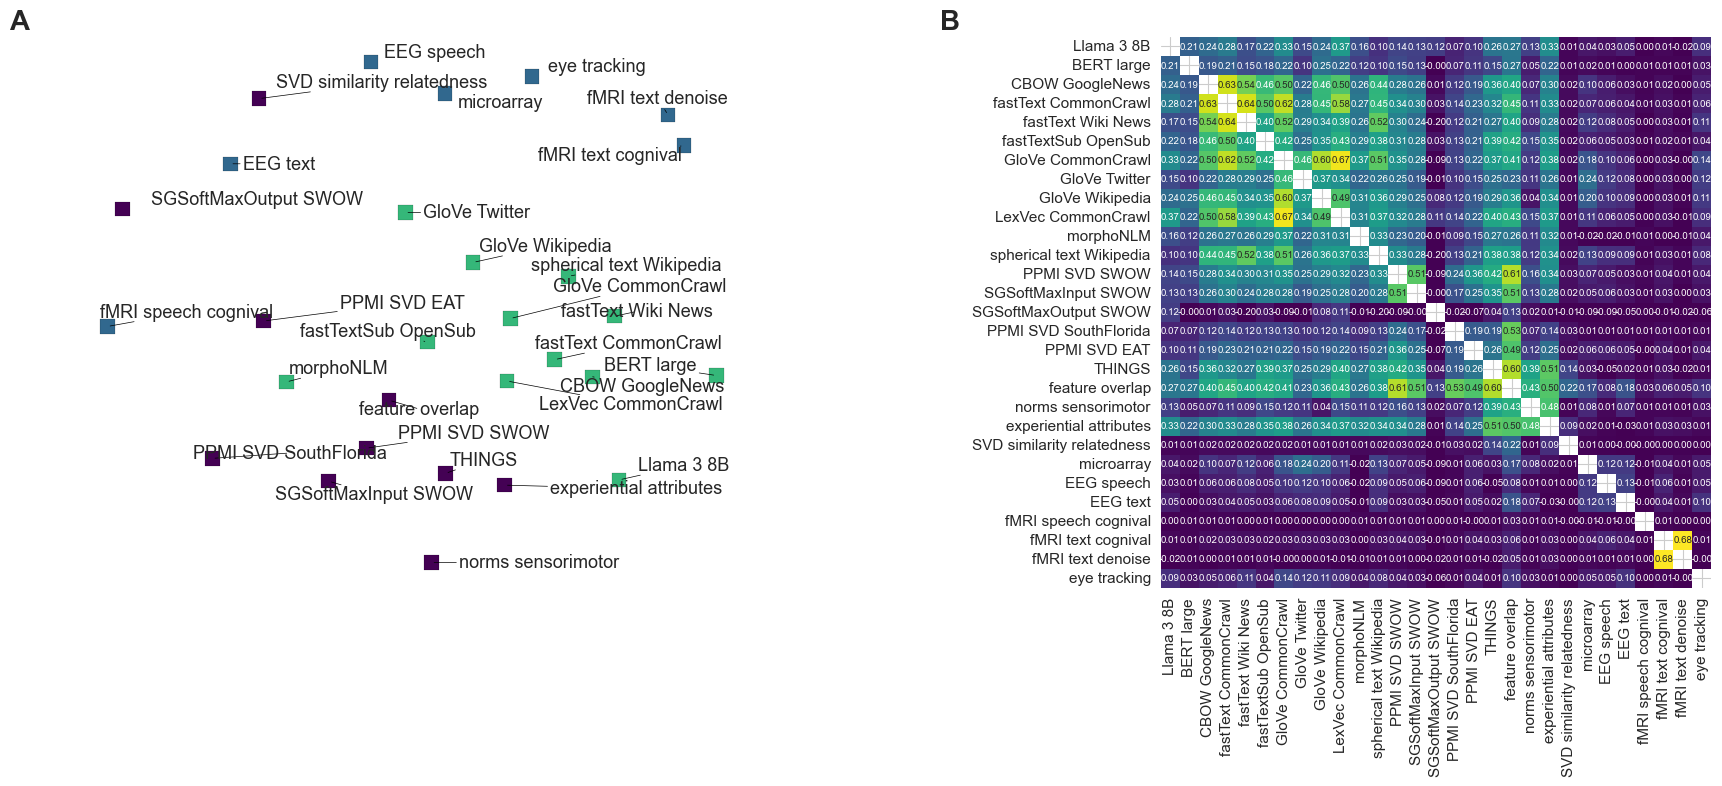

In [8]:
def plot_scatter_panel(ax, spearmans_2d, embed_type_to_color, spearmans, add_label=False):
    if add_label:
        annot_fontsize = 13
    else:
        annot_fontsize = 12
    
    sns.scatterplot(
        data=spearmans_2d, x=0, y=1, hue='embed_type',
        sizes=(500, 500), legend=False, s=110,
        marker='s', linewidth=0.1, edgecolor='black',
        palette=embed_type_to_color, ax=ax
    )

    # Remove axis labels/ticks
    ax.set(xticklabels='', yticklabels='', xlabel='', ylabel='')

    # Add text labels for points
    texts = []
    for model in spearmans.index:
        texts.append(
            ax.text(
                spearmans_2d[0][model],
                spearmans_2d[1][model],
                model.replace('_', ' '),
                fontsize=annot_fontsize
            )
        )
    adjust_text(
        texts, arrowprops=dict(arrowstyle='-', color='black', lw=.5), ax=ax
    )

    ax.axis('off')
    
    # Optionally add the panel label
    if add_label:
        ax.text(
            -0.1, 1.05, 'A',
            transform=ax.transAxes,
            fontsize=20,
            fontweight='bold',
            va='top'
        )


def plot_heatmap_panel(ax, spearmans, add_label=False):
    """
    Draws the heatmap on the given Axes object `ax`.
    If add_label is True, draw the bold panel label 'B' on the panel.
    """
    if add_label:
        annot_fontsize = 7
        ticklabel_fontsize = 11
    else:
        annot_fontsize = 5
        ticklabel_fontsize = 9
    
    sns.heatmap(
        spearmans, square=True, annot=True, cmap='viridis',
        vmin=0, vmax=spearmans.max().max(), 
        fmt='.2f', annot_kws={"fontsize": annot_fontsize}, cbar=False, ax=ax
    )

    # Increase font size of x and y tick labels
    ax.tick_params(axis='both', which='major', labelsize=ticklabel_fontsize)

    # Optionally add the panel label
    if add_label:
        ax.text(
            -0.4, 1.05, 'B',
            transform=ax.transAxes,
            fontsize=20,
            fontweight='bold',
            va='top'
        )


# Create a 1-row, 2-column figure
fig, (ax_1, ax_2) = plt.subplots(1, 2, figsize=(20, 8), width_ratios=(0.6, 1))

# Plot each panel, adding the labels:
plot_scatter_panel(ax_1, spearmans_2d, embed_type_to_color, spearmans, add_label=True)
plot_heatmap_panel(ax_2, spearmans, add_label=True)

fig.tight_layout()
plt.savefig('../../figures/rsa.png', dpi=300, bbox_inches='tight')
plt.show()